# Day 14 — Food Delivery Business Performance Visualization


# 1. Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [2]:
# Load the dataset

df = pd.read_csv("/content/Day14_Food_Delivery_Visualization_Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# 3. View Dataset

In [3]:
# Display first 5 rows

df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [4]:
# Check dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 360
Columns: 16


In [5]:
# Display column names

print(df.columns)

Index(['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine',
       'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue',
       'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes',
       'Customer_Rating', 'Repeat_Customer_Percent'],
      dtype='object')


# 4. Prepare Date Column

Since we need a **line plot over time**, convert the date column first.

In [6]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


# 5. Line Plot — Orders Over Time

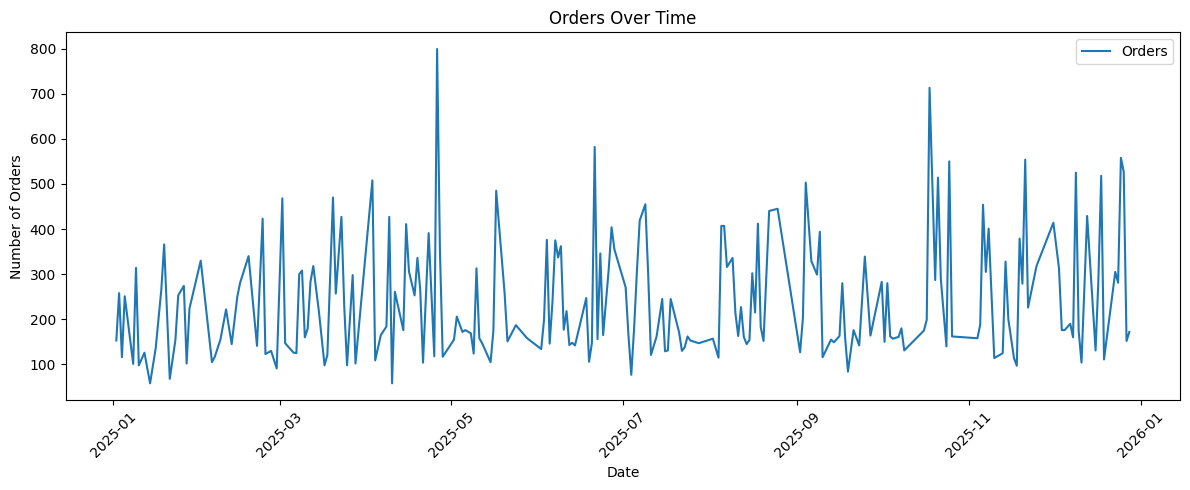

In [7]:
# Calculate daily orders

daily_orders = df.groupby("Date")["Orders"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_orders.index,
    daily_orders.values,
    label="Orders"
)

plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

The line plot shows how the number of orders changes over time. The number of orders varies across different dates, showing that customer demand is not constant throughout the period.

# 6. Line Plot — Revenue Over Time

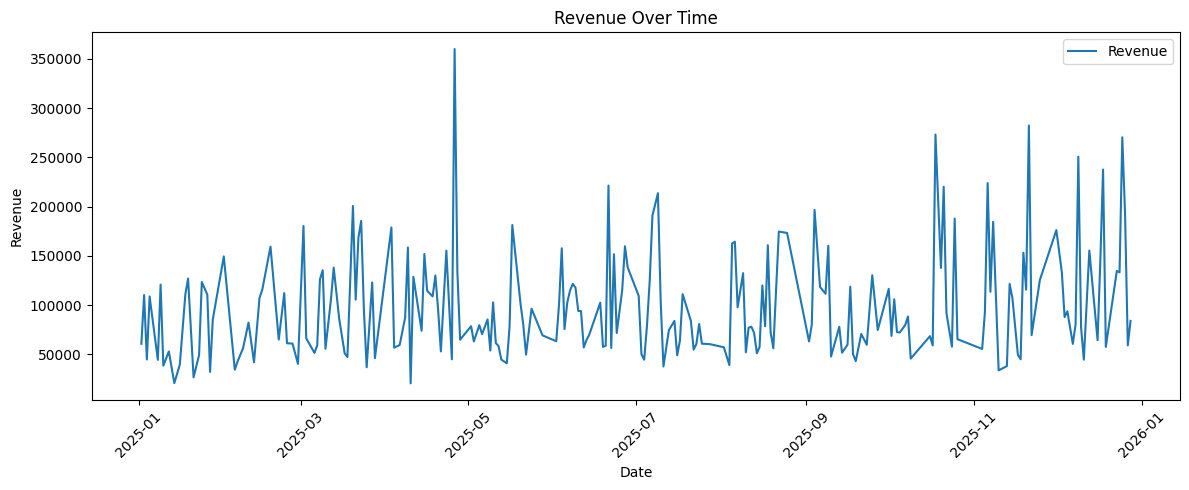

In [8]:
# Calculate daily revenue

daily_revenue = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_revenue.index,
    daily_revenue.values,
    label="Revenue"
)

plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Revenue changes over time along with order activity. Some dates generate considerably higher revenue than others, indicating variation in business performance.

# 7. Bar Chart — Revenue by City

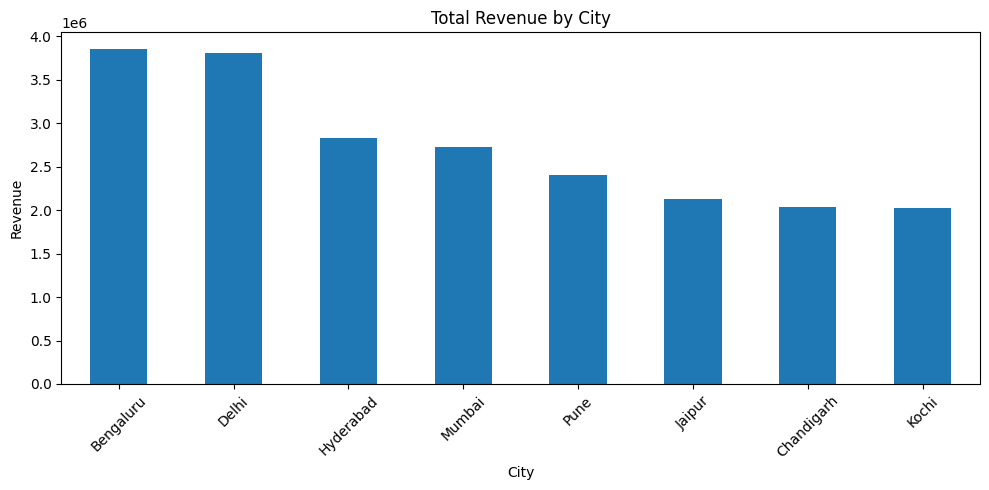

In [9]:
# Calculate revenue by city

city_revenue = df.groupby("City")["Revenue"].sum()

plt.figure(figsize=(10, 5))

city_revenue.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Total Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Bengaluru generates the highest total revenue among the cities, followed closely by Delhi. Chandigarh and Kochi generate the lowest total revenue in the dataset.

# 8. Bar Chart — Revenue by Cuisine

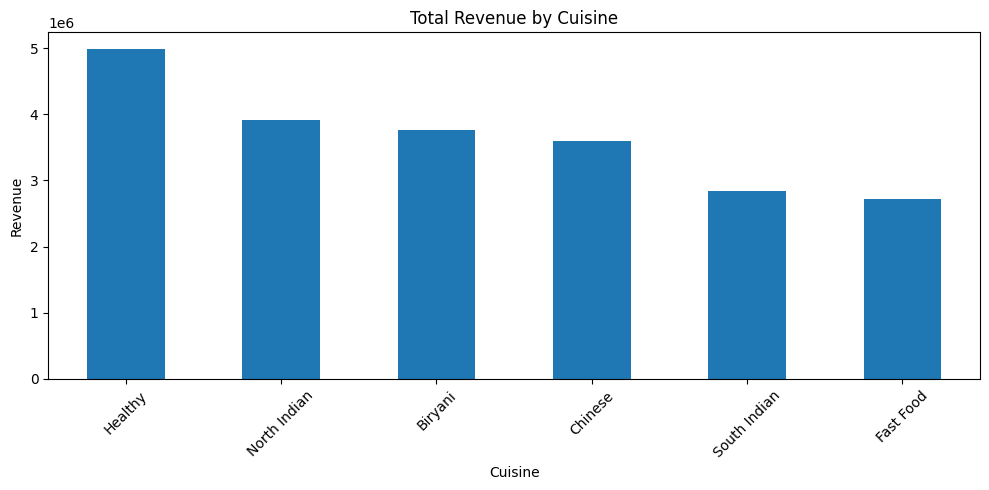

In [10]:
# Calculate revenue by cuisine

cuisine_revenue = df.groupby("Cuisine")["Revenue"].sum()

plt.figure(figsize=(10, 5))

cuisine_revenue.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Total Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Healthy cuisine generates the highest total revenue, followed by North Indian and Biryani cuisines. Fast Food generates the lowest total revenue among the cuisines.

# 9. Scatter Plot — Marketing Spend vs Revenue

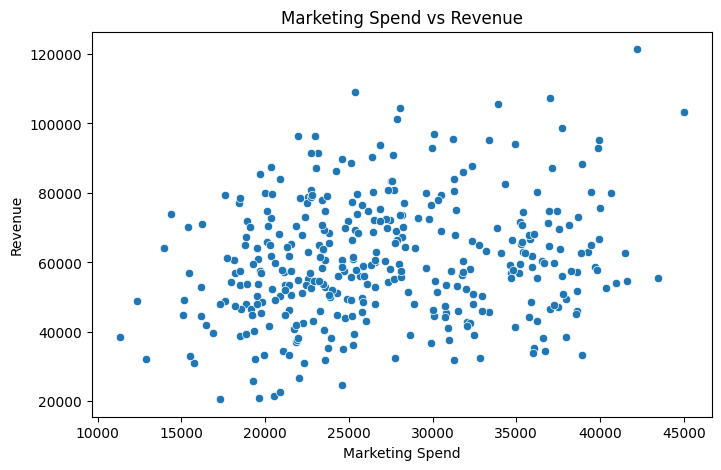

In [11]:
# Marketing spend vs revenue

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue"
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")

plt.show()

# 10. Scatter Plot — Delivery Time vs Customer Rating

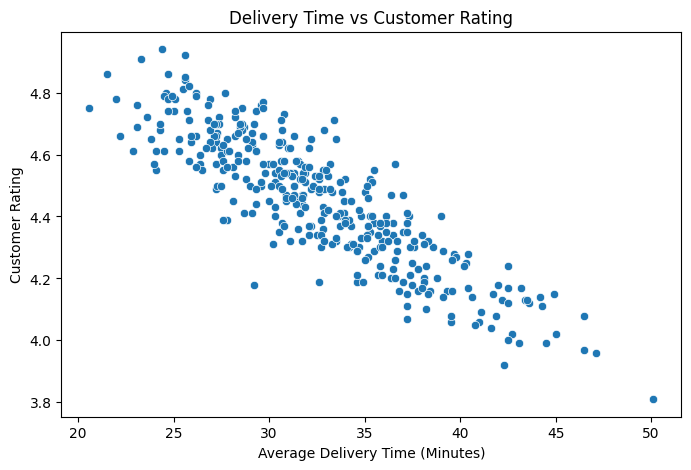

In [12]:
# Delivery time vs customer rating

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating"
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")

plt.show()

### Interpretation

The points are widely scattered, showing that delivery time does not have a strong linear relationship with customer rating in this dataset.

# 11. Histogram — Orders

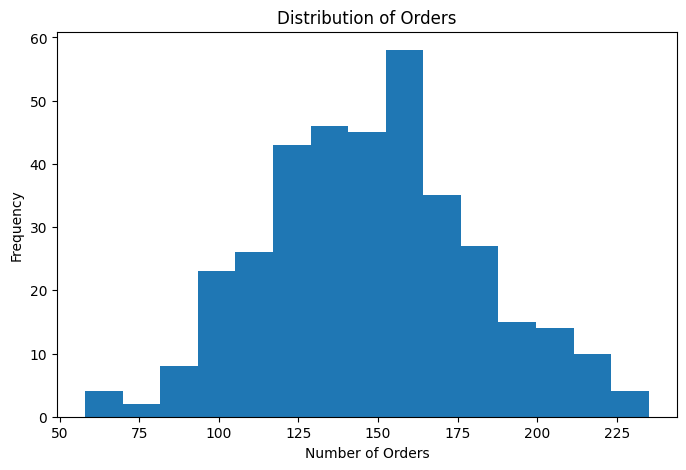

In [13]:
# Distribution of orders

plt.figure(figsize=(8, 5))

plt.hist(
    df["Orders"],
    bins=15
)

plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Most order batches contain a moderate number of orders, while very high or very low order counts occur less frequently.

# 12. Histogram — Customer Rating

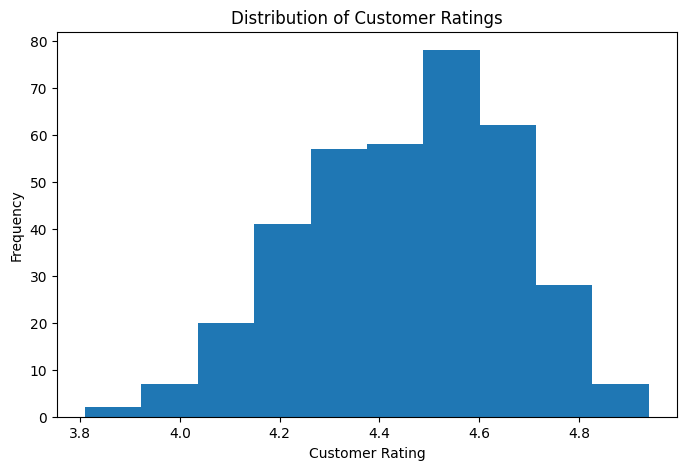

In [14]:
# Distribution of customer ratings

plt.figure(figsize=(8, 5))

plt.hist(
    df["Customer_Rating"],
    bins=10
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")

plt.show()

### Interpretation

Customer ratings are generally high. The average rating is approximately 4.45, showing that customers are mostly satisfied with the service.

# 13. Box Plot — Revenue

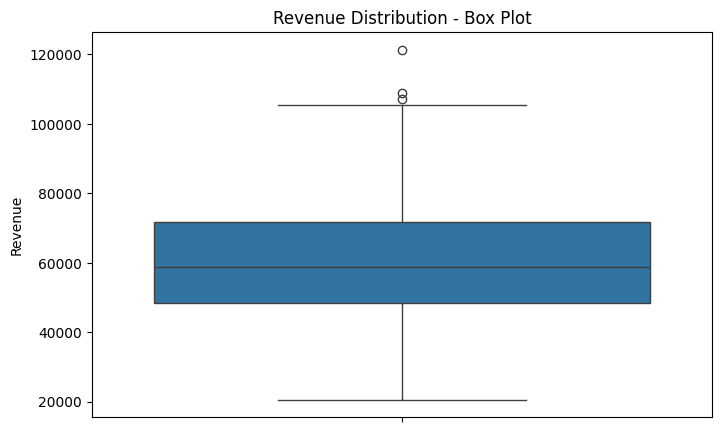

In [15]:
# Box plot of revenue

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df["Revenue"]
)

plt.title("Revenue Distribution - Box Plot")
plt.ylabel("Revenue")

plt.show()

### Interpretation

The box plot shows the spread of revenue and helps identify unusually high or low revenue values. The dataset contains some high-revenue observations compared with the typical revenue level.

# 14. Box Plot — Revenue by City

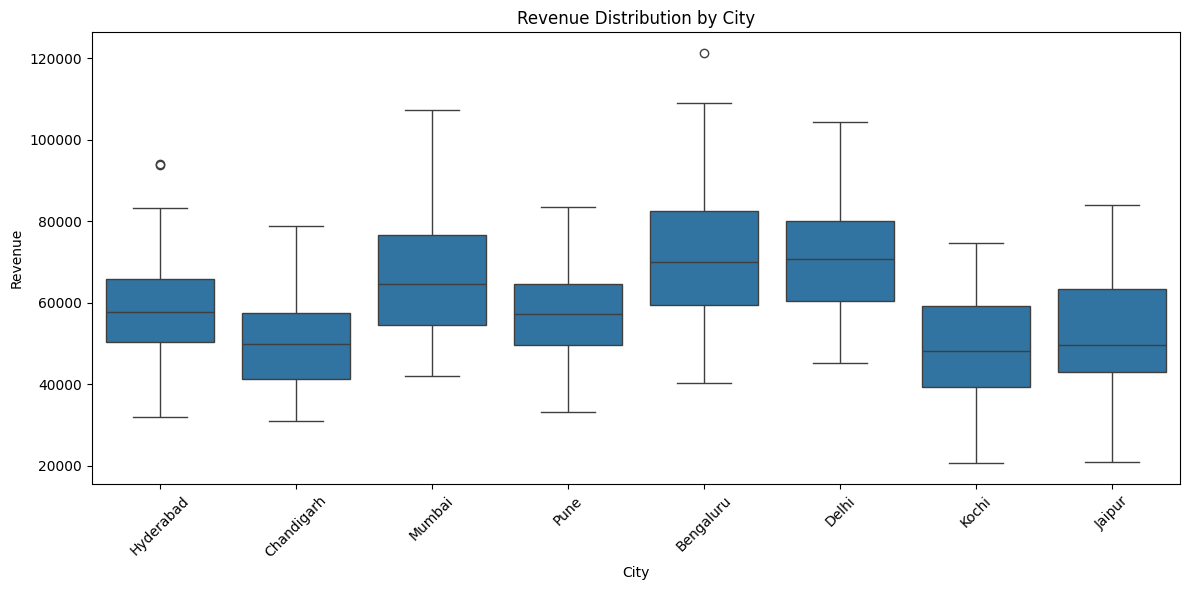

In [16]:
# Revenue distribution by city

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Revenue"
)

plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Revenue varies within each city. Some cities have higher typical revenue values and wider variation than others.

# 15. Violin Plot — Customer Rating by Weather

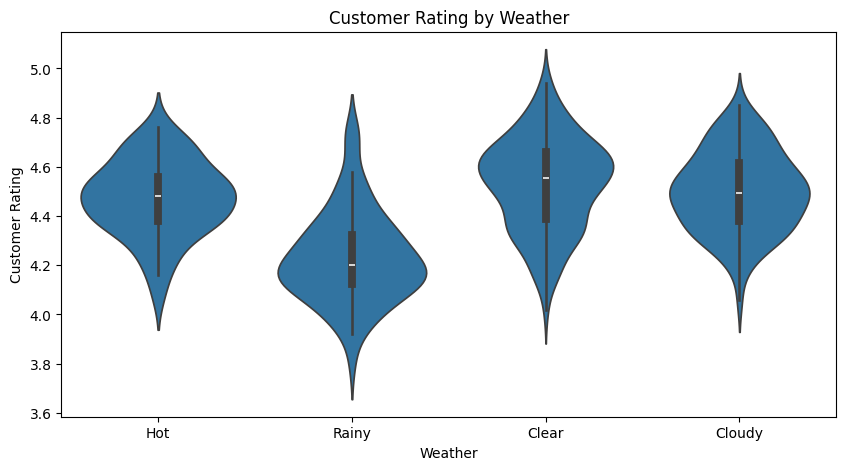

In [17]:
# Customer ratings under different weather conditions

plt.figure(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="Weather",
    y="Customer_Rating"
)

plt.title("Customer Rating by Weather")
plt.xlabel("Weather")
plt.ylabel("Customer Rating")

plt.show()

# 16. Count Plot — Order Channel

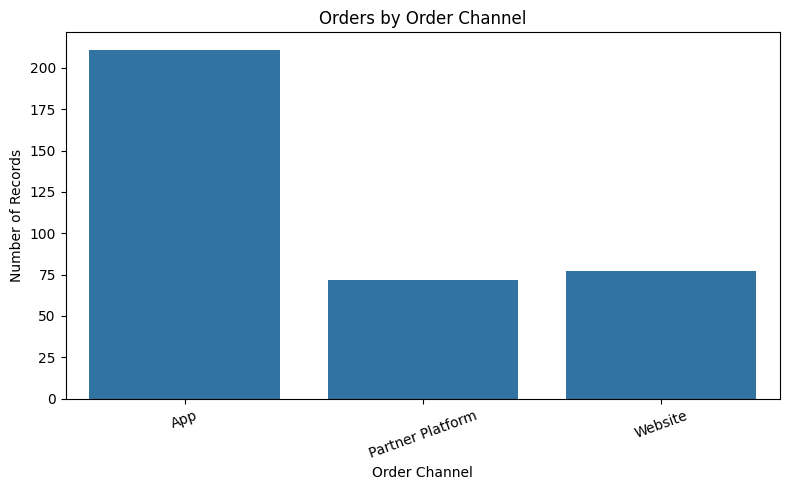

In [18]:
# Count orders by order channel

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Order_Channel"
)

plt.title("Orders by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Number of Records")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

# 17. Count Plot — Weather

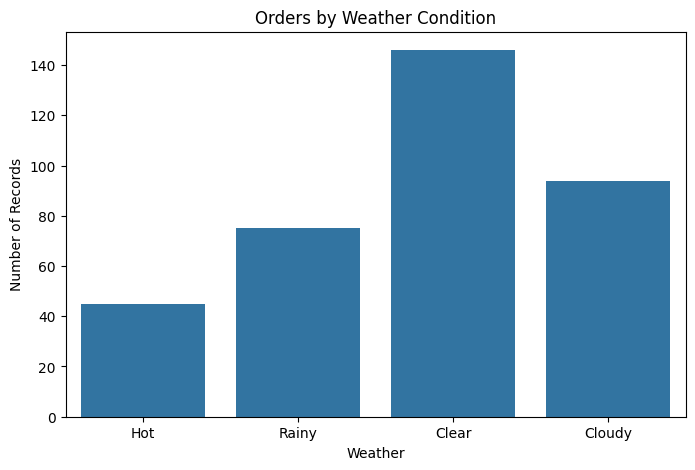

In [19]:
# Count records by weather condition

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.title("Orders by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Records")

plt.show()

### Interpretation

Clear weather is the most common weather condition in the dataset, while Hot weather occurs less frequently.

# 18. Revenue by Order Channel

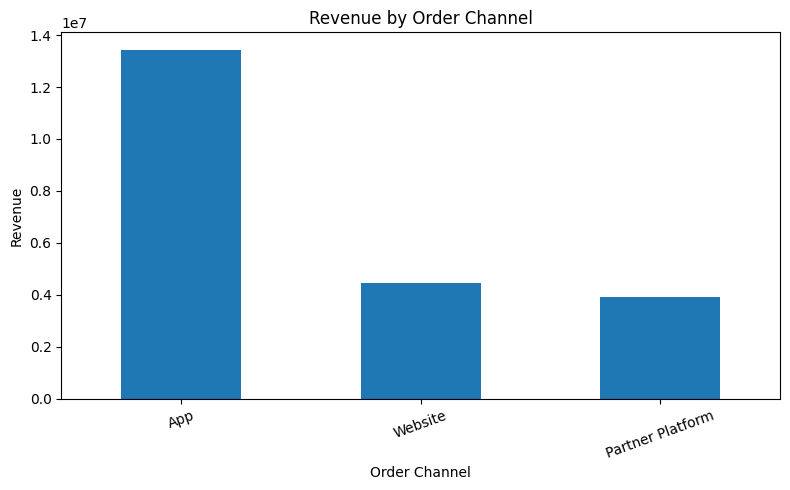

In [20]:
# Revenue by order channel

channel_revenue = df.groupby(
    "Order_Channel"
)["Revenue"].sum()

plt.figure(figsize=(8, 5))

channel_revenue.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Revenue")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

### Interpretation

The App generates the highest total revenue among the order channels. Website and Partner Platform contribute less total revenue.

In fact, the App generated approximately **₹1.34 crore** in total revenue in this dataset.

# 19. Revenue by Weather

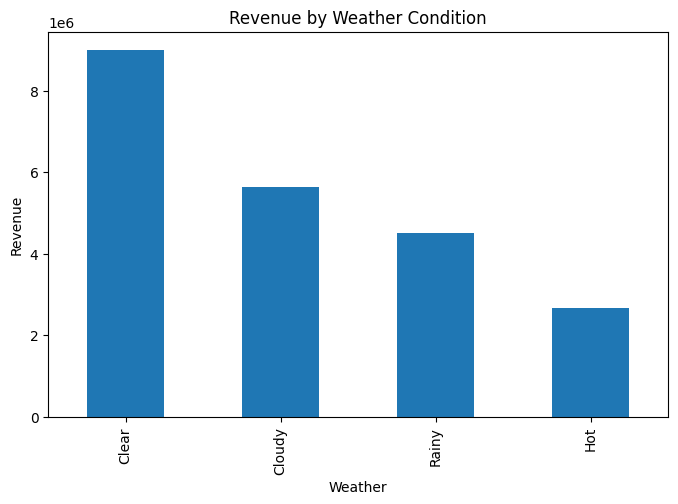

In [21]:
# Revenue under different weather conditions

weather_revenue = df.groupby(
    "Weather"
)["Revenue"].sum()

plt.figure(figsize=(8, 5))

weather_revenue.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Revenue by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Revenue")

plt.show()

### Interpretation

Clear weather generates the highest total revenue, while Hot weather generates the lowest total revenue among the weather categories.

# 20. Correlation Matrix

Now we'll analyze relationships between the numerical variables.

In [22]:
# Select numerical columns

numeric_data = df.select_dtypes(
    include="number"
)

numeric_data.head()

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [23]:
# Calculate correlation matrix

correlation_matrix = numeric_data.corr()

correlation_matrix

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
Orders,1.000000,-0.010645,0.759617,0.179173,0.403633,0.124756,-0.110504,-0.004926
Average_Order_Value,-0.010645,1.000000,0.579619,0.079387,0.298327,-0.055923,0.016393,0.053220
Revenue,0.759617,0.579619,1.000000,0.198127,0.524685,0.047182,-0.056375,0.030634
Marketing_Spend,0.179173,0.079387,0.198127,1.000000,0.751785,-0.028608,0.051583,0.046916
Discounts,0.403633,0.298327,0.524685,0.751785,1.000000,-0.016603,0.043929,0.088643
Avg_Delivery_Minutes,0.124756,-0.055923,0.047182,-0.028608,-0.016603,1.000000,-0.875881,-0.759633
Customer_Rating,-0.110504,0.016393,-0.056375,0.051583,0.043929,-0.875881,1.000000,0.824341
Repeat_Customer_Percent,-0.004926,0.053220,0.030634,0.046916,0.088643,-0.759633,0.824341,1.000000


# 21. Correlation Heatmap

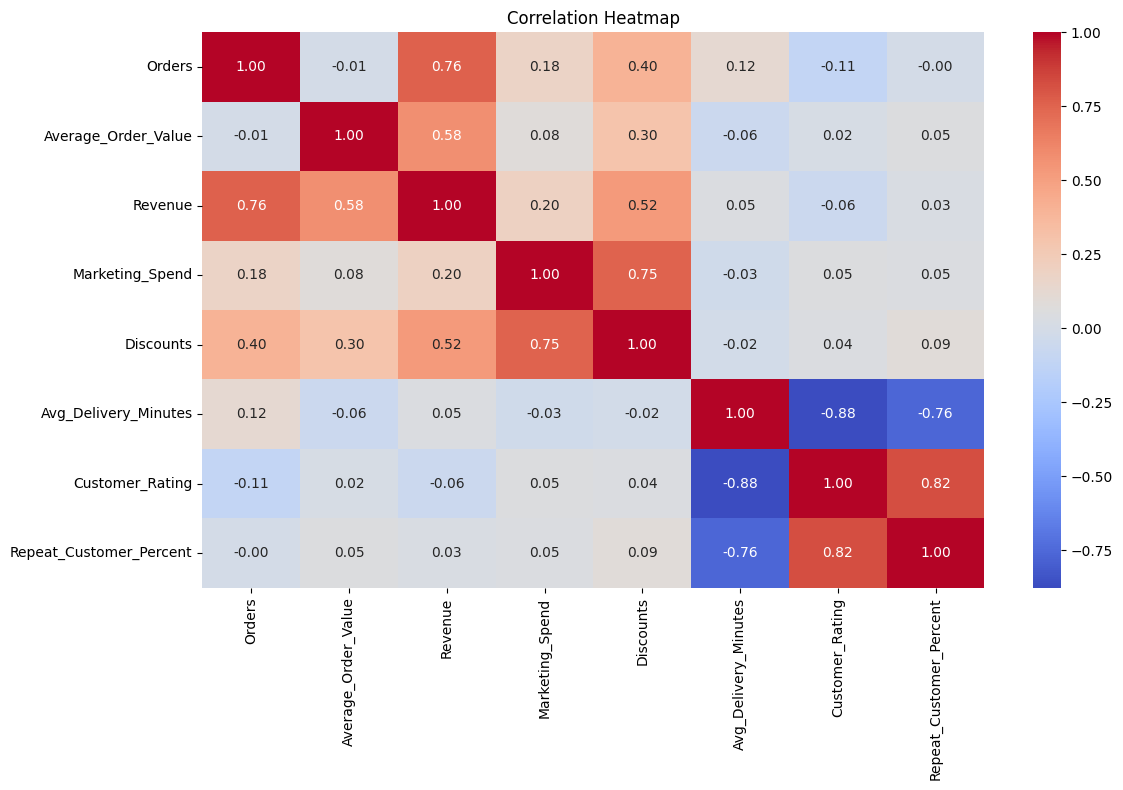

In [24]:
# Create correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# 22. Find Top City

In [25]:
# Find the city with the highest revenue

top_city = city_revenue.idxmax()

print("Top City:", top_city)
print("Revenue:", city_revenue.max())

Top City: Bengaluru
Revenue: 3851958.65


# 23. Find Top Cuisine

In [26]:
# Find the cuisine with the highest revenue

top_cuisine = cuisine_revenue.idxmax()

print("Top Cuisine:", top_cuisine)
print("Revenue:", cuisine_revenue.max())

Top Cuisine: Healthy
Revenue: 4988656.66


# 24. Overall Summary

In [27]:
# Overall business summary

print("========== FOOD DELIVERY SUMMARY ==========")

print("Total Orders:", df["Orders"].sum())
print("Total Revenue: ₹", round(df["Revenue"].sum(), 2))

# Calculate Average Order Value before printing
# Assuming Average_Order_Value is a column or can be derived
# If 'Average_Order_Value' column doesn't exist, this line will cause an error.
# Let's assume it exists from the user provided data context.
print("Average Order Value: ₹", round(df["Average_Order_Value"].mean(), 2))

print("Average Customer Rating:", round(df["Customer_Rating"].mean(), 2))
print("Average Delivery Time:", round(df["Avg_Delivery_Minutes"].mean(), 2), "minutes")

print("Top City:", top_city)
print("Top Cuisine:", top_cuisine)

========== FOOD DELIVERY SUMMARY ==========
Total Orders: 53153
Total Revenue: ₹ 21812801.32
Average Order Value: ₹ 409.15
Average Customer Rating: 4.45
Average Delivery Time: 32.58 minutes
Top City: Bengaluru
Top Cuisine: Healthy
